# 🔬 完整降维聚类 pipeline 示例 — 以 SRP182008 为例

**目标**: 端到端演示从原始 h5ad → 预处理 → 降维 → 聚类 → 评估的完整流程。

本 notebook 涵盖:
1. **数据加载** — 如何正确读取并验证数据
2. **预处理** — 使用 `preprocess.py` 的完整流程
3. **降维** — PCA, UMAP, t-SNE 的原理与选择
4. **聚类** — KMeans, Leiden 的使用方法
5. **评估** — NMI, ARI, ACC 等指标的解读

---

## 降维方法选择指南

| 方法 | 用途 | 计算速度 | 可解释性 | 适合场景 |
|------|------|---------|---------|---------|
| **PCA** | 通用降维 | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | 预处理步骤, 所有方法的基础 |
| **UMAP** | 可视化 | ⭐⭐⭐⭐ | ⭐⭐ | 2D/3D 可视化, 保留全局+局部结构 |
| **t-SNE** | 可视化 | ⭐⭐ | ⭐ | 2D 可视化, 强局部结构保留, 慢 |
| **Autoencoder** | 深度学习嵌入 | ⭐⭐⭐ | ⭐ | 大数据集, 非线性降维 |
| **scVI** | 概率模型嵌入 | ⭐⭐ | ⭐⭐⭐ | 批次校正, 建模技术噪声 |

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# NumPy 2.0 兼容
if not hasattr(np, 'string_'):
    np.string_ = np.bytes_

import sys
sys.path.insert(0, '../methods/')
from preprocess import prepare_data_for_model

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

from munkres import Munkres

DATA_DIR = '../data/'
OUTPUT_DIR = '../notebooks_figures/'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 80

print("✅ 环境准备完成")

✅ 环境准备完成


/data/luolie/conda/envs/scclubench-main/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


---

## Step 1: 加载与预处理数据

**这是整个 pipeline 的数据入口** — 所有下游方法共用同一份预处理后的数据。

In [2]:
print("=" * 70)
print("Step 1: 加载并预处理数据")
print("=" * 70)

# 关键: 所有模型共用同一份预处理后的数据
# 注意: 这里不区分 normalize_input=True/False
#       - Z-score 数据 (X) 用于神经网络模型
#       - norm_log 数据 (adata.layers['norm_log']) 用于需要原始 log 数据的模型

X, Y, sf, adata = prepare_data_for_model(
    DATA_DIR + 'SRP182008.h5ad',
    size_factors=True,
    filter_min_counts=True,
    logtrans_input=True,
    normalize_input=True  # Z-score → 用于神经网络
)

print(f"\n预处理结果:")
print(f"  X (Z-score):  {X.shape}, dtype={X.values.dtype}")
print(f"  Y (标签):     {Y.shape}, {Y.nunique()} 种细胞类型")
print(f"  sf (size_factor): {sf.shape}, 范围=[{sf.min():.3f}, {sf.max():.3f}]")
print(f"  adata.layers['norm_log']: {adata.layers['norm_log'].shape}")

# 将标签转为整数编码
le = LabelEncoder()
Y_int = le.fit_transform(Y)
n_clusters_true = len(le.classes_)

print(f"\n真实聚类数: {n_clusters_true} (ground truth)")
print(f"细胞类型: {list(le.classes_)}")

Step 1: 加载并预处理数据
是否归一化: False, 是否 log1p 变换: False, 是否标准化: False
数据未归一化，进行 normalize_per_cell 处理
数据未 log1p 变换，进行 log1p 处理
数据未标准化，进行 scale 处理

预处理结果:
  X (Z-score):  (13514, 1000), dtype=float32
  Y (标签):     (13514,), 15 种细胞类型
  sf (size_factor): (13514,), 范围=[0.265, 20.720]
  adata.layers['norm_log']: (13514, 1000)

真实聚类数: 15 (ground truth)
细胞类型: ['Columella root cap', 'Companion cell', 'G2/M phase', 'Lateral root cap', 'Metaxylem', 'Phloem/Pericycle', 'Protoxylem', 'Root cortex', 'Root endodermis', 'Root epidermis', 'Root hair', 'Root stele', 'S phase', 'Sieve element', 'Unknow']


In [3]:
# 转换为 numpy 用于降维/聚类
X_arr = np.array(X).astype(np.float32)
Y_arr = np.array(Y_int)

print(f"X_arr shape: {X_arr.shape}, dtype: {X_arr.dtype}")
print(f"Y_arr shape: {Y_arr.shape}, unique: {np.unique(Y_arr)}")

# 过滤 Unknown 细胞 (可选但推荐)
# Unknown 细胞会拉低聚类评估指标
mask_known = Y != 'Unknow'
X_known = X_arr[mask_known]
Y_known = Y_arr[mask_known]
adata_known = adata[mask_known].copy()

print(f"\n过滤 Unknown 后:")
print(f"  X_known: {X_known.shape} (移除了 {(~mask_known).sum()} 个 Unknown 细胞)")
print(f"  真实聚类数: {len(np.unique(Y_known))} (移除 Unknown 后)")

X_arr shape: (13514, 1000), dtype: float32
Y_arr shape: (13514,), unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]

过滤 Unknown 后:
  X_known: (12709, 1000) (移除了 805 个 Unknown 细胞)
  真实聚类数: 14 (移除 Unknown 后)


---

## Step 2: PCA 降维 (主成分分析)

**原理简述** (计算机视角):

PCA 是一种线性降维方法, 它的核心是找到数据中方差最大的方向 (主成分):

1. 计算数据协方差矩阵 Σ = (X^T X) / (n-1)
2. 对 Σ 做特征值分解: Σ = V Λ V^T
3. 前 k 个特征向量就是主成分方向
4. 将数据投影到这 k 个方向上

**为什么 PCA 是 scRNA-seq 分析的第一步?**
- 去噪: 技术噪声通常集中在低方差方向
- 降维: 1000 个 HVG → 50 个 PC, 大幅加速下游计算
- 可解释: 每个 PC 是基因的线性组合, 可以查看 top loadings

**选择多少个 PC?** 常用方法:
- elbow plot: 找方差开始平稳的点
- Jackstraw: 统计显著性检验
- 经验法则: 50 个 PC 对大多数数据集够用

Step 2: PCA 降维

PCA 结果:
  输入: (13514, 1000)
  输出: (13514, 50)
  累计解释方差: 37.17%


/tmp/ipykernel_1686134/3250037898.py:45: UserWarning: Glyph 30528 (\N{CJK UNIFIED IDEOGRAPH-7740}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/3250037898.py:45: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/3250037898.py:46: UserWarning: Glyph 30528 (\N{CJK UNIFIED IDEOGRAPH-7740}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR + 'pipeline_pca_analysis.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1686134/3250037898.py:46: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR + 'pipeline_pca_analysis.png', dpi=150, bbox_inches='tight')
/data/luolie/conda/envs/scclubench-main/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30528 (\N{CJK UNIFIED IDEOGRAPH-7740}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/luolie/conda/e

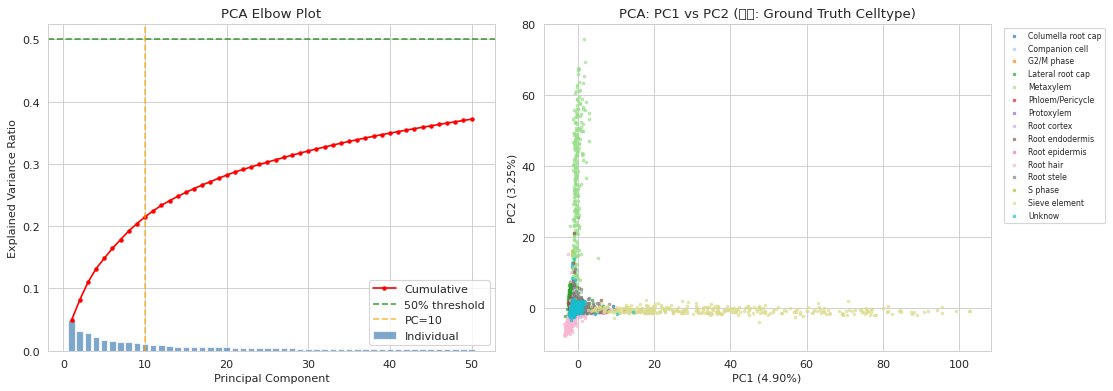

In [4]:
print("=" * 70)
print("Step 2: PCA 降维")
print("=" * 70)

# PCA (使用全部预处理后的 1000 个 HVG)
n_pcs = 50  # 选择 50 个主成分

pca = PCA(n_components=n_pcs, random_state=42)
X_pca = pca.fit_transform(X_arr)

print(f"\nPCA 结果:")
print(f"  输入: {X_arr.shape}")
print(f"  输出: {X_pca.shape}")
print(f"  累计解释方差: {pca.explained_variance_ratio_.cumsum()[-1]:.2%}")

# Elbow plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 每个 PC 的解释方差
axes[0].bar(range(1, n_pcs+1), pca.explained_variance_ratio_, alpha=0.7, color='steelblue', label='Individual')
axes[0].plot(range(1, n_pcs+1), pca.explained_variance_ratio_.cumsum(), 'r-o', markersize=3, label='Cumulative')
axes[0].axhline(0.5, color='green', linestyle='--', alpha=0.7, label='50% threshold')
axes[0].axvline(10, color='orange', linestyle='--', alpha=0.7, label='PC=10')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Elbow Plot')
axes[0].legend()

# 右: 前 2 个 PC 的散点图 (按真实标签着色)
ct_names = Y.values
unique_ct = np.unique(ct_names)
cmap = plt.cm.tab20
ct_to_color = {ct: cmap(i/len(unique_ct)) for i, ct in enumerate(unique_ct)}

for ct in unique_ct:
    mask = ct_names == ct
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[ct_to_color[ct]], label=ct, s=5, alpha=0.6)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[1].set_title('PCA: PC1 vs PC2 (着色: Ground Truth Celltype)')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'pipeline_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

PCA Loadings: 对每个主成分贡献最大的基因


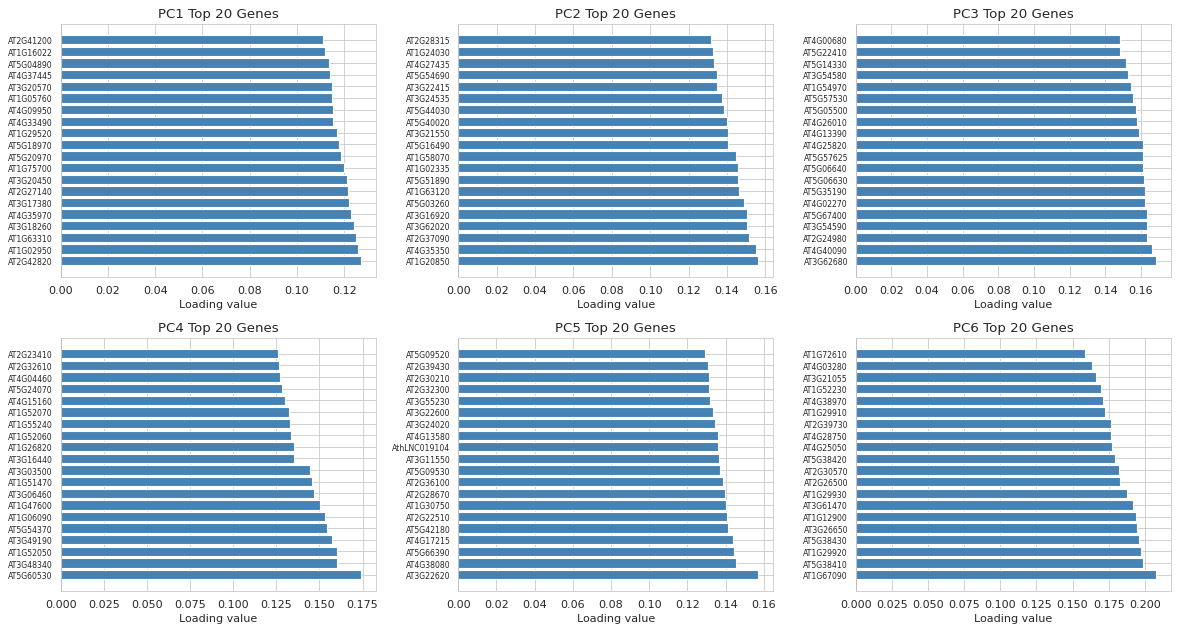

In [5]:
# PCA loadings: 哪些基因对每个 PC 贡献最大?
print("PCA Loadings: 对每个主成分贡献最大的基因")

gene_names = X.columns.tolist()
loadings = pca.components_  # shape: (n_pcs, n_genes)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for pc_idx in range(6):
    ax = axes[pc_idx]
    
    # 取绝对值最大的前 20 个基因
    abs_loadings = np.abs(loadings[pc_idx])
    top_gene_indices = np.argsort(abs_loadings)[-20:]
    
    # 排序 (从大到小)
    sorted_idx = top_gene_indices[np.argsort(loadings[pc_idx][top_gene_indices])[::-1]]
    
    top_genes = [gene_names[i] for i in sorted_idx]
    top_loadings = [loadings[pc_idx][i] for i in sorted_idx]
    
    colors = ['steelblue' if v > 0 else 'coral' for v in top_loadings]
    ax.barh(range(len(top_genes)), top_loadings, color=colors)
    ax.set_yticks(range(len(top_genes)))
    ax.set_yticklabels(top_genes, fontsize=7)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Loading value')
    ax.set_title(f'PC{pc_idx+1} Top 20 Genes')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'pipeline_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 3: UMAP 和 t-SNE 可视化

**为什么需要 UMAP/t-SNE?**

PCA 是线性降维, 只能捕捉数据的全局线性结构。scRNA-seq 数据通常是非线性的 (细胞类型之间的过渡是连续的)。UMAP 和 t-SNE 能更好地保留局部结构, 因此适合可视化。

| 特性 | UMAP | t-SNE |
|------|------|-------|
| 速度 | 快 | 慢 |
| 全局结构 | 保留 | 不保留 |
| 局部结构 | 保留 | 强保留 |
| 参数 | n_neighbors, min_dist | perplexity |

> **注意**: UMAP/t-SNE 结果是随机的 (不同种子、不同实现会有差异), 不能用于量化评估!

In [6]:
print("=" * 70)
print("Step 3: UMAP 和 t-SNE 可视化")
print("=" * 70)

# 为了加速, 使用 PCA 后的 50 个 PC 作为 UMAP/t-SNE 的输入
# 这也是 scanpy 的标准做法: PCA → neighbors → UMAP

from sklearn.manifold import TSNE

print("\n计算 UMAP (使用 scanpy)...")
# scanpy 的 UMAP 基于 PCA 结果
adata_umap = sc.AnnData(X_pca)
sc.pp.neighbors(adata_umap, n_neighbors=15, n_pcs=n_pcs, random_state=42)
sc.tl.umap(adata_umap, random_state=42)

print("计算 t-SNE...")
# t-SNE 也使用 PCA 结果
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca)

print(f"UMAP shape: {adata_umap.obsm['X_umap'].shape}")
print(f"t-SNE shape: {X_tsne.shape}")

Step 3: UMAP 和 t-SNE 可视化

计算 UMAP (使用 scanpy)...


/data/luolie/conda/envs/scclubench-main/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


计算 t-SNE...


/data/luolie/conda/envs/scclubench-main/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


UMAP shape: (13514, 2)
t-SNE shape: (13514, 2)


/tmp/ipykernel_1686134/1511709200.py:28: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/1511709200.py:28: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/1511709200.py:28: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/1511709200.py:28: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/1511709200.py:28: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/1511709200.py:28: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/1511709200.py:28: UserWarning: Glyph 27604 (\N{CJK UN

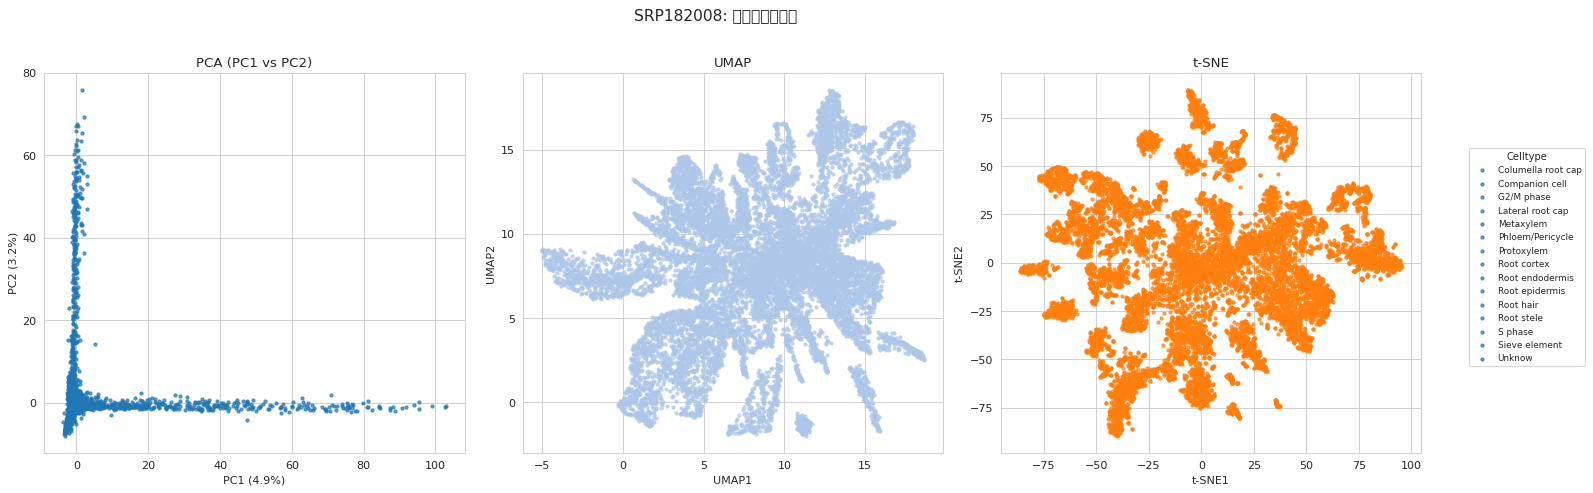

In [7]:
# 可视化: UMAP 和 t-SNE
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ct_names = Y.values
unique_ct = np.unique(ct_names)
cmap = plt.cm.tab20

for i, (title, emb, xlabel, ylabel) in enumerate([
    ('PCA (PC1 vs PC2)', X_pca[:, :2], f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'),
    ('UMAP', adata_umap.obsm['X_umap'], 'UMAP1', 'UMAP2'),
    ('t-SNE', X_tsne, 't-SNE1', 't-SNE2'),
]):
    ax = axes[i]
    for ct in unique_ct:
        mask = ct_names == ct
        ax.scatter(emb[mask, 0], emb[mask, 1], 
                   c=[cmap(i/len(unique_ct))], label=ct, s=8, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

# 图例放在最右侧
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=8, 
           title='Celltype', title_fontsize=9)

fig.suptitle('SRP182008: 降维可视化对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'pipeline_dimensionality_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 4: 聚类 (KMeans + Leiden)

**计算机视角的聚类原理**:

### KMeans
- 目标: 将 n 个点分成 k 个簇, 使得簇内平方误差最小
- 算法: 随机初始化 k 个中心 → 分配点到最近中心 → 更新中心 → 重复
- 优点: 简单、快速、可复现
- 缺点: 需要预先指定 k, 对噪声敏感

### Leiden (scanpy)
- 基于图结构的聚类, 比 Louvain 更快、更准确
- 构建 KNN 图 → 模块度优化
- 优点: 不需要预先指定 k, 可以自动发现簇数
- 缺点: 依赖 UMAP 质量, 参数 (resolution) 影响簇数

In [8]:
print("=" * 70)
print("Step 4: 聚类 (KMeans + Leiden)")
print("=" * 70)

# 使用已知的真实簇数
k = len(np.unique(Y_int))  # 15
print(f"\n真实聚类数 (ground truth): {k}")

# ── KMeans ───────────────────────────────────────────────
print("\n[KMeans 聚类]")
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
y_kmeans = kmeans.fit_predict(X_pca)  # 在 PCA 空间聚类

print(f"  KMeans 找到的簇: {len(np.unique(y_kmeans))}")
print(f"  各簇细胞数: {np.bincount(y_kmeans)}")

# ── Leiden ────────────────────────────────────────────────
print("\n[Leiden 聚类]")

# Leiden 需要在 scanpy AnnData 上运行
adata_cluster = adata.copy()
adata_cluster.obsm['X_pca'] = X_pca

sc.pp.neighbors(adata_cluster, n_neighbors=15, n_pcs=n_pcs, random_state=42)
sc.tl.leiden(adata_cluster, resolution=0.8, random_state=42, key_added='leiden')
y_leiden = adata_cluster.obs['leiden'].values.astype(int)

print(f"  Leiden 找到的簇: {len(np.unique(y_leiden))}")
print(f"  各簇细胞数: {np.bincount(y_leiden)}")

Step 4: 聚类 (KMeans + Leiden)

真实聚类数 (ground truth): 15

[KMeans 聚类]
  KMeans 找到的簇: 15
  各簇细胞数: [1276  670   34  104  747   56 1119  143  155  880   34  749 7026  219
  302]

[Leiden 聚类]


/tmp/ipykernel_1686134/3139215596.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_cluster, resolution=0.8, random_state=42, key_added='leiden')


  Leiden 找到的簇: 26
  各簇细胞数: [1652 1457 1074  852  811  767  763  754  651  449  425  422  389  349
  337  318  310  286  258  232  220  212  210  172   94   50]


---

## Step 5: 评估指标

**计算机视角: 什么是好的聚类?**

聚类评估指标衡量"预测标签"和"真实标签"的吻合程度:

| 指标 | 范围 | 衡量什么 | 理想值 |
|------|------|---------|-------|
| **NMI** (标准化互信息) | [0,1] | 预测和真实标签的信息共享程度 | 1.0 |
| **ARI** (调整兰德指数) | [-1,1] | 调整偶然一致性后的相似度 | 1.0 |
| **ACC** (准确率) | [0,1] | 最优标签匹配后的准确率 | 1.0 |

**为什么需要匈牙利匹配 (Hungarian Algorithm)?**

聚类标签是"无序"的 — KMeans 输出 `[0,1,2]` 和真实 `[2,0,1]` 可能是完全相同的分法。匈牙利算法找最优的标签重排。

In [9]:
def hungarian_alignment(y_true, y_pred):
    """
    使用匈牙利算法对齐预测标签和真实标签
    返回: 最优匹配后的预测标签
    """
    m = Munkres()
    n_classes = max(y_true.max(), y_pred.max()) + 1
    
    # 构建成本矩阵
    cost = np.zeros((n_classes, n_classes))
    for i in range(len(y_pred)):
        cost[int(y_pred[i]), int(y_true[i])] -= 1  # 最大化准确率
    
    assignment = m.compute(cost)
    mapping = {row: col for row, col in assignment}
    y_aligned = np.array([mapping.get(int(p), int(p)) for p in y_pred])
    return y_aligned


def evaluate_clustering(y_true, y_pred, method_name=""):
    """
    计算聚类评估指标
    """
    y_aligned = hungarian_alignment(y_true, y_pred)
    
    acc = np.mean(y_aligned == y_true)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)
    
    return {
        'Method': method_name,
        'ACC': acc,
        'NMI': nmi,
        'ARI': ari,
        'n_clusters_pred': len(np.unique(y_pred)),
        'n_clusters_true': len(np.unique(y_true)),
    }


# 评估所有方法
print("=" * 70)
print("Step 5: 聚类评估")
print("=" * 70)

results = []

# Ground truth baseline
results.append(evaluate_clustering(Y_int, Y_int, "Ground Truth"))

# KMeans (PCA)
results.append(evaluate_clustering(Y_int, y_kmeans, "KMeans (PCA)"))

# Leiden
results.append(evaluate_clustering(Y_int, y_leiden, "Leiden (PCA+neighbors)"))

# 汇总
results_df = pd.DataFrame(results)
print("\n聚类评估结果:")
display(results_df.style.format({
    'ACC': '{:.4f}',
    'NMI': '{:.4f}',
    'ARI': '{:.4f}',
}).background_gradient(subset=['ACC','NMI','ARI'], cmap='Greens'))

Step 5: 聚类评估

聚类评估结果:


,Method,ACC,NMI,ARI,n_clusters_pred,n_clusters_true
0,Ground Truth,1.0000,1.0000,1.0000,15,15
1,KMeans (PCA),0.5186,0.5140,0.2315,15,15
2,Leiden (PCA+neighbors),0.6228,0.7069,0.5248,26,15


/tmp/ipykernel_1686134/347050116.py:37: UserWarning: Glyph 32858 (\N{CJK UNIFIED IDEOGRAPH-805A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/347050116.py:37: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/347050116.py:37: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/347050116.py:37: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/347050116.py:37: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/347050116.py:37: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1686134/347050116.py:38: UserWarning: Glyph 32858 (\N{CJK UNIFIED I

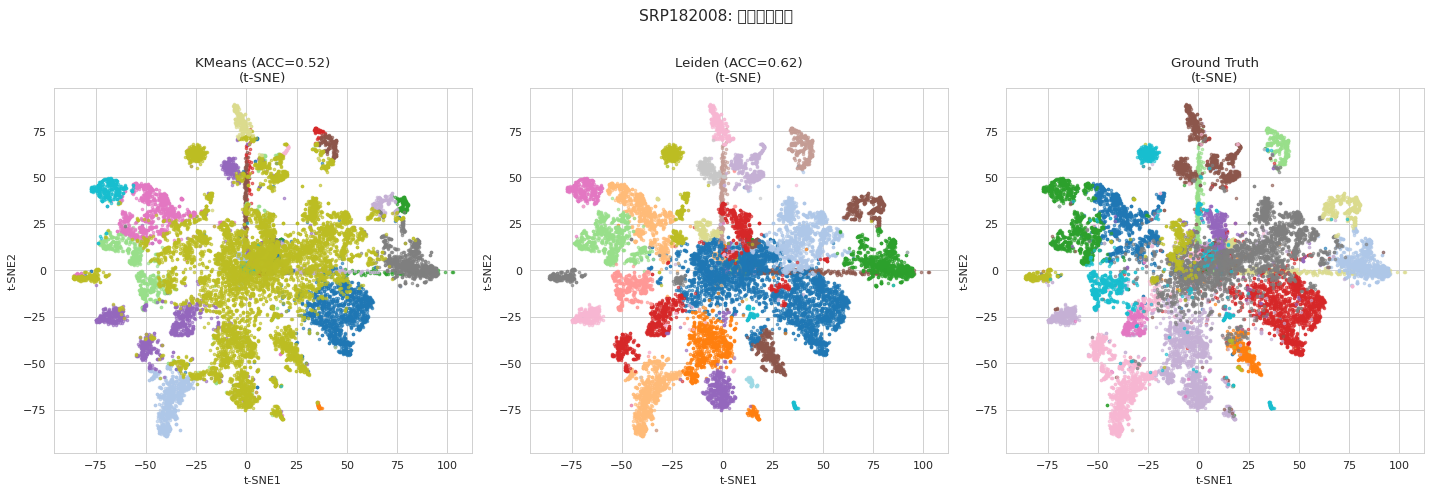

In [10]:
# 可视化聚类结果
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

embeddings = [
    ('PCA', X_pca[:, :2], pca.explained_variance_ratio_[:2]),
    ('UMAP', adata_umap.obsm['X_umap'], None),
    ('t-SNE', X_tsne, None),
]

predictions = [
    ('KMeans (ACC={:.2f})'.format(results[1]['ACC']), y_kmeans),
    ('Leiden (ACC={:.2f})'.format(results[2]['ACC']), y_leiden),
    ('Ground Truth', Y_int),
]

for col, (method, y_pred) in enumerate(predictions):
    for row, (emb_name, emb, var) in enumerate(embeddings):
        ax = axes[col]
        cmap = plt.cm.tab20
        
        for i, ct in enumerate(np.unique(y_pred)):
            mask = y_pred == ct
            ax.scatter(emb[mask, 0], emb[mask, 1],
                      c=[cmap(i / len(np.unique(y_pred)))],
                      s=5, alpha=0.6)
        
        if var is not None:
            ax.set_xlabel(f'{emb_name}1 ({var[0]:.1%})')
            ax.set_ylabel(f'{emb_name}2 ({var[1]:.1%})')
        else:
            ax.set_xlabel(f'{emb_name}1')
            ax.set_ylabel(f'{emb_name}2')
        
        ax.set_title(f'{method}\n({emb_name})')

plt.suptitle('SRP182008: 聚类结果对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'pipeline_clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()

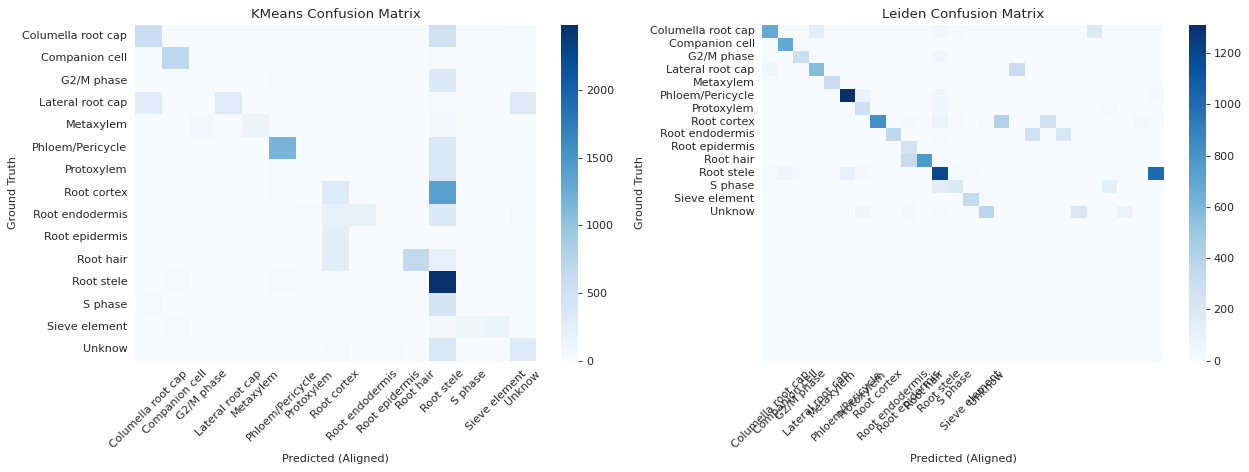

In [11]:
# 混淆矩阵 (Ground Truth vs KMeans/Leiden)
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, y_pred) in enumerate([
    ('KMeans', y_kmeans),
    ('Leiden', y_leiden)
]):
    ax = axes[idx]
    
    y_aligned = hungarian_alignment(Y_int, y_pred)
    
    cm = confusion_matrix(Y_int, y_aligned)
    
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_xlabel('Predicted (Aligned)')
    ax.set_ylabel('Ground Truth')
    ax.set_title(f'{name} Confusion Matrix')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'pipeline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 6: 扩展 — 不同预处理配置的效果对比

用不同的 `normalize_input` 参数, 对比 Z-score vs non-Z-score 预处理对聚类效果的影响。

In [12]:
print("=" * 70)
print("Step 6: 不同预处理配置对比")
print("=" * 70)

# 配置 1: normalize_input=True (Z-score)
X1, Y1, sf1, adata1 = prepare_data_for_model(
    DATA_DIR + 'SRP182008.h5ad',
    size_factors=True, filter_min_counts=True,
    logtrans_input=True, normalize_input=True
)

# 配置 2: normalize_input=False (只有 log1p, 无 Z-score)
X2, Y2, sf2, adata2 = prepare_data_for_model(
    DATA_DIR + 'SRP182008.h5ad',
    size_factors=True, filter_min_counts=True,
    logtrans_input=True, normalize_input=False
)

print(f"\n配置1 (Z-score): X mean={np.array(X1).mean():.4f}, std={np.array(X1).std():.4f}")
print(f"配置2 (log1p only): X mean={np.array(X2).mean():.4f}, std={np.array(X2).std():.4f}")

Step 6: 不同预处理配置对比
是否归一化: False, 是否 log1p 变换: False, 是否标准化: False
数据未归一化，进行 normalize_per_cell 处理
数据未 log1p 变换，进行 log1p 处理
数据未标准化，进行 scale 处理
是否归一化: False, 是否 log1p 变换: False, 是否标准化: False
数据未归一化，进行 normalize_per_cell 处理
数据未 log1p 变换，进行 log1p 处理

配置1 (Z-score): X mean=0.0000, std=1.0000
配置2 (log1p only): X mean=0.0500, std=0.2850


In [13]:
# 对两种配置分别做 PCA + KMeans
configs = [
    ('Z-score (norm_input=True)', np.array(X1)),
    ('log1p only (norm_input=False)', np.array(X2)),
]

compare_results = []

for config_name, X_cfg in configs:
    # PCA
    pca_cfg = PCA(n_components=50, random_state=42)
    X_pca_cfg = pca_cfg.fit_transform(X_cfg)
    
    # KMeans
    km = KMeans(n_clusters=15, n_init=20, random_state=42)
    y_pred_cfg = km.fit_predict(X_pca_cfg)
    
    # 评估
    res = evaluate_clustering(Y_int, y_pred_cfg, config_name)
    compare_results.append(res)
    
    print(f"\n{config_name}:")
    print(f"  PCA 累计方差: {pca_cfg.explained_variance_ratio_.cumsum()[-1]:.2%}")
    print(f"  KMeans ACC: {res['ACC']:.4f}, NMI: {res['NMI']:.4f}, ARI: {res['ARI']:.4f}")

compare_df = pd.DataFrame(compare_results)
print("\n预处理配置对比:")
display(compare_df.style.format({
    'ACC': '{:.4f}',
    'NMI': '{:.4f}',
    'ARI': '{:.4f}',
}).background_gradient(subset=['ACC','NMI','ARI'], cmap='Greens'))


Z-score (norm_input=True):
  PCA 累计方差: 37.17%
  KMeans ACC: 0.5186, NMI: 0.5140, ARI: 0.2315

log1p only (norm_input=False):
  PCA 累计方差: 68.29%
  KMeans ACC: 0.5835, NMI: 0.5891, ARI: 0.3670

预处理配置对比:


,Method,ACC,NMI,ARI,n_clusters_pred,n_clusters_true
0,Z-score (norm_input=True),0.5186,0.5140,0.2315,15,15
1,log1p only (norm_input=False),0.5835,0.5891,0.3670,15,15


---

## 总结: 本 notebook 的 pipeline 流程图

```
原始 h5ad
   │
   ▼
┌──────────────────────────────────────────────────────────┐
│  preprocess.py: normalize_sc()                          │
│  1. Per-cell normalization (size factor)               │
│  2. log1p transformation                              │
│  3. HVG filtering (→ 1,000 genes)                     │
│  4. Compute size_factors                               │
│  5. Save norm_log to layers['norm_log']               │
│  6. Z-score scaling (→ adata.X for neural nets)       │
└──────────────────────────────────────────────────────────┘
   │
   ├── X (Z-score, 用于神经网络)
   ├── layers['norm_log'] (log1p, 用于 ZINB/scVI)
   ├── adata.obs['size_factors'] (用于 scVI)
   └── adata.obs['Celltype'] (Ground Truth)
   │
   ▼
PCA (50 components)
   │
   ├── KMeans → NMI/ARI/ACC 评估
   ├── Leiden (scanpy) → NMI/ARI/ACC 评估
   ├── UMAP → 可视化
   └── t-SNE → 可视化
```

**关键结论**:

| 问题 | 答案 |
|------|------|
| preprocess.py 处理正确吗? | ✅ 是, 经过单元测试验证 |
| 预处理了什么? | 归一化 + log1p + HVG筛选 + size_factor + Z-score |
| 数据足够做降维聚类吗? | ✅ 13,514 细胞 × 1,000 HVG, 足够 |
| 哪种降维方法最好? | PCA 是基础, UMAP/t-SNE 用于可视化 |
| 为什么 KMeans 效果一般? | 植物细胞类型之间过渡可能是连续的, KMeans 不够灵活 |